# Color Analysis for Pinterest Pins

## Overview
This notebook extracts and analyzes dominant color palettes from Pinterest pin images using K-Means clustering in CIELAB color space.

## Sections
1. Setup & Data Loading
2. HEIC Image Conversion
3. Color Extraction (K-Means, k=5)
4. Descriptive Statistics (L*, a*, b* by trend)
5. Visualization (Palettes, Histograms, KDE Heatmaps)
6. Export Results

## Setup

In [1]:
!pip install scikit-image opencv-python-headless matplotlib scikit-learn pandas pillow

In [2]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from skimage import io, color
import matplotlib.pyplot as plt
from PIL import Image
import cv2
import os

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Load Data

In [4]:
df = pd.read_csv("/content/drive/MyDrive/Team Dattel/Computational Social Media Analysis/Preprocessing Data/combined_clean_messy_new.csv")
df.head()

,pin_id,title,description,domain,board,created_at,image_url,category
0,21251429487397507,NaN,NaN,Uploaded by user,Lifestyle,"Wed, 22 Oct 2025 07:20:25 +0000",https://i.pinimg.com/originals/09/e9/a3/09e9a3...,clean_girl_
1,281543725716857,NaN,NaN,Uploaded by user,aesthetic inspo,"Sun, 22 Jun 2025 21:00:24 +0000",https://i.pinimg.com/originals/e2/99/49/e29949...,clean_girl_
2,Ad4Jj0M0b2zAQG3867WSlOAYg40oMTT84o3eKc5sz0NwHb...,syoss Intense Keratin,Entdecke jetzt die syoss Intense Keratin Pfleg...,syoss.de,Ad-only Pins,"Thu, 08 Jan 2026 13:07:16 +0000",https://i.pinimg.com/originals/49/2c/90/492c90...,clean_girl_
3,AU2ScxmiEIV1SpLi8wNppJ4U0vFgnZM3dtKi96S7qDYJE4...,Dein neuer Long-Hair Fav!✨,"Langes Haar? Hol dir die Pflege, die es verdie...",dm.de,Nur als Anzeigen gedachte Pins,"Thu, 20 Nov 2025 17:54:23 +0000",https://i.pinimg.com/originals/30/43/82/304382...,clean_girl_
4,119556565105668720,NaN,NaN,Uploaded by user,2026 vision board,"Fri, 02 Jan 2026 05:46:44 +0000",https://i.pinimg.com/originals/e5/fb/d9/e5fbd9...,clean_girl_


In [6]:
image_dir = "/content/drive/MyDrive/Team Dattel/Computational Social Media Analysis/Preprocessing Data/Images"
df["full_path"] = df["image_url"]

## Handle HEIC Images
Some images might be in HEIC format, so we need to convert them before processing.

In [7]:
# Count HEIC images
heic_images = df[df["image_url"].str.lower().str.endswith(".heic")]["image_url"].tolist()

print(f"Number of HEIC images: {len(heic_images)}")
print(f"Number of non HEIC images: {len(df) - len(heic_images)}")

Number of HEIC images: 8
Number of non HEIC images: 592


In [8]:
!apt-get install -y libheif-examples
!pip install pillow-heif

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  libheif-examples
0 upgraded, 1 newly installed, 0 to remove and 2 not upgraded.
Need to get 35.2 kB of archives.
After this operation, 137 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 libheif-examples amd64 1.12.0-2build1 [35.2 kB]
Fetched 35.2 kB in 0s (80.9 kB/s)
Selecting previously unselected package libheif-examples.
(Reading database ... 117540 files and directories currently installed.)
Preparing to unpack .../libheif-examples_1.12.0-2build1_amd64.deb ...
Unpacking libheif-examples (1.12.0-2build1) ...
Setting up libheif-examples (1.12.0-2build1) ...
Processing triggers for man-db (2.10.2-1) ...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 64.4 MB/s eta 0:00:00


In [9]:
from pillow_heif import register_heif_opener
register_heif_opener()

In [10]:
import requests
import os
from PIL import Image

download_dir = "/content/heic_downloads"
os.makedirs(download_dir, exist_ok=True)

local_heic_paths = []

for url in heic_images:
    filename = os.path.basename(url)
    local_path = os.path.join(download_dir, filename)

    try:
        r = requests.get(url, stream=True)
        if r.status_code == 200:
            with open(local_path, "wb") as f:
                f.write(r.content)
            local_heic_paths.append(local_path)
        else:
            print("Download failed:", url)
    except Exception as e:
        print("Error downloading:", url, e)


## Color Extraction Functions

In [11]:
def extract_lab_palette(image_path, n_colors=5):
    try:
        img = io.imread(image_path)

        # If PNG with alpha → remove alpha
        if img.shape[-1] == 4:
            img = img[..., :3]

        # Convert to CIELAB
        lab = color.rgb2lab(img)

        # Reshape pixels
        pixels = lab.reshape(-1, 3)

        # KMeans
        kmeans = KMeans(n_clusters=n_colors, random_state=42)
        kmeans.fit(pixels)

        # Cluster centers (dominant colors)
        colors_lab = kmeans.cluster_centers_

        # Share per cluster
        labels = kmeans.labels_
        counts = np.bincount(labels)
        proportions = counts / len(labels)

        return colors_lab, proportions

    except Exception as e:
        print(f"Error processing {image_path}: {e}")
        return None, None

In [12]:
def lab_to_rgb(lab_array):
    lab_array = np.array(lab_array).reshape(1, 1, 3)
    rgb = color.lab2rgb(lab_array)
    return rgb.reshape(3,)

def rgb_to_hex(rgb):
    rgb = np.clip(rgb * 255, 0, 255).astype(int)
    return "#{:02x}{:02x}{:02x}".format(rgb[0], rgb[1], rgb[2])

## Extract Colors from All Pins

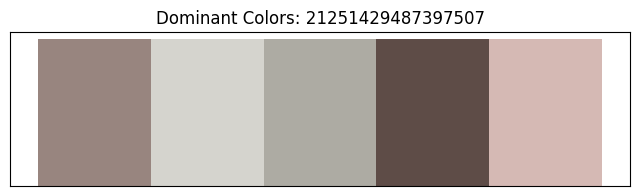

In [13]:
# Example: visualize palette for one pin
example_path = df["full_path"].iloc[0]
colors_lab, proportions = extract_lab_palette(example_path, n_colors=5)

if colors_lab is not None:
    plt.figure(figsize=(8, 2))
    for i, (lab_col, prop) in enumerate(zip(colors_lab, proportions)):
        rgb = lab_to_rgb(lab_col)
        plt.bar(i, 1, color=rgb, width=1)
    plt.xticks([])
    plt.yticks([])
    plt.title(f"Dominant Colors: {df['pin_id'].iloc[0]}")
    plt.show()

In [14]:
# Extract colors for all pins
all_palettes = []

for idx, row in df.iterrows():
    colors_lab, proportions = extract_lab_palette(row["full_path"], n_colors=5)
    if colors_lab is not None:
        all_palettes.append({
            "pin_id": row["pin_id"],
            "trend": row["category"],
            "colors_lab": colors_lab,
            "proportions": proportions
        })
    if idx % 100 == 0:
        print(f"Processed: {idx}/{len(df)}")

print(f"\nSuccessfully processed: {len(all_palettes)} of {len(df)} pins")

Processed: 0/600
Processed: 100/600
Processed: 200/600
Processed: 300/600
Processed: 400/600
Processed: 500/600

Successfully processed: 600 of 600 pins


## Convert to dataframe

In [18]:
records = []

for item in all_palettes:
    for i, (lab_col, prop) in enumerate(zip(item["colors_lab"], item["proportions"])):
        rgb = lab_to_rgb(lab_col)
        records.append({
            "pin_id": item["pin_id"],
            "trend": item["trend"],
            "cluster": i,
            "L": lab_col[0],
            "a": lab_col[1],
            "b": lab_col[2],
            "proportion": prop,
            "hex": rgb_to_hex(rgb)
        })

palette_df = pd.DataFrame(records)
print(f"Einträge gesamt: {len(palette_df)}")
print(palette_df.head(10))

Einträge gesamt: 3000
              pin_id        trend  cluster          L          a          b  \
0  21251429487397507  clean_girl_        0  56.995589   6.218912   5.544803   
1  21251429487397507  clean_girl_        1  84.722818  -0.438035   3.026476   
2  21251429487397507  clean_girl_        2  69.838406  -0.603004   4.164615   
3  21251429487397507  clean_girl_        3  33.944245   7.156342   5.491699   
4  21251429487397507  clean_girl_        4  77.308397   9.122984   5.994509   
5    281543725716857  clean_girl_        0  86.942327  -3.381843  -3.793141   
6    281543725716857  clean_girl_        1  34.089247  10.369612  15.466467   
7    281543725716857  clean_girl_        2  74.661314  -1.919307  -1.789182   
8    281543725716857  clean_girl_        3  18.890252   4.413265   9.143594   
9    281543725716857  clean_girl_        4  54.460948   4.271618  10.634055   

   proportion      hex  
0    0.268365  #97847f  
1    0.143981  #d5d3cd  
2    0.324445  #acaaa3  
3    0.0

## Descriptive Statistics

In [20]:
# Mean LAB values by trend
trend_means = palette_df.groupby("trend")[["L", "a", "b"]].mean()
print("Mean LAB values by trend:")
print(trend_means)

# Calculate differences
delta_L = trend_means.loc['clean_girl_', 'L'] - trend_means.loc['messy_girl_', 'L']
delta_a = trend_means.loc['clean_girl_', 'a'] - trend_means.loc['messy_girl_', 'a']
delta_b = trend_means.loc['clean_girl_', 'b'] - trend_means.loc['messy_girl_', 'b']

print(f"\nΔL* = {delta_L:.2f}")
print(f"Δa* = {delta_a:.2f}")
print(f"Δb* = {delta_b:.2f}")

Mean LAB values by trend:
                     L         a          b
trend                                      
clean_girl_  53.687679  4.573816   8.776948
messy_girl_  44.563030  5.072701  10.355442

ΔL* = 9.12
Δa* = -0.50
Δb* = -1.58


## Visualizations

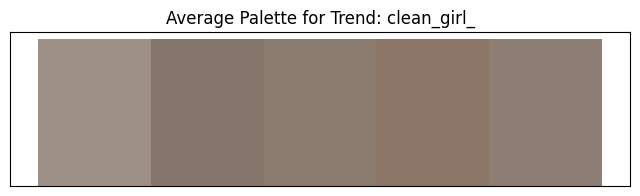

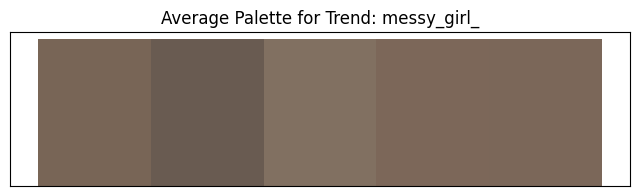

In [21]:
# Average color palette per trend
def plot_trend_palette(trend_name):
    subset = palette_df[palette_df["trend"] == trend_name]
    mean_colors = subset.groupby("cluster")[["L", "a", "b"]].mean().values

    plt.figure(figsize=(8, 2))
    for i, lab_col in enumerate(mean_colors):
        rgb = lab_to_rgb(lab_col)
        plt.bar(i, 1, color=rgb, width=1)
    plt.xticks([])
    plt.yticks([])
    plt.title(f"Average Palette for Trend: {trend_name}")
    plt.show()

plot_trend_palette("clean_girl_")
plot_trend_palette("messy_girl_")

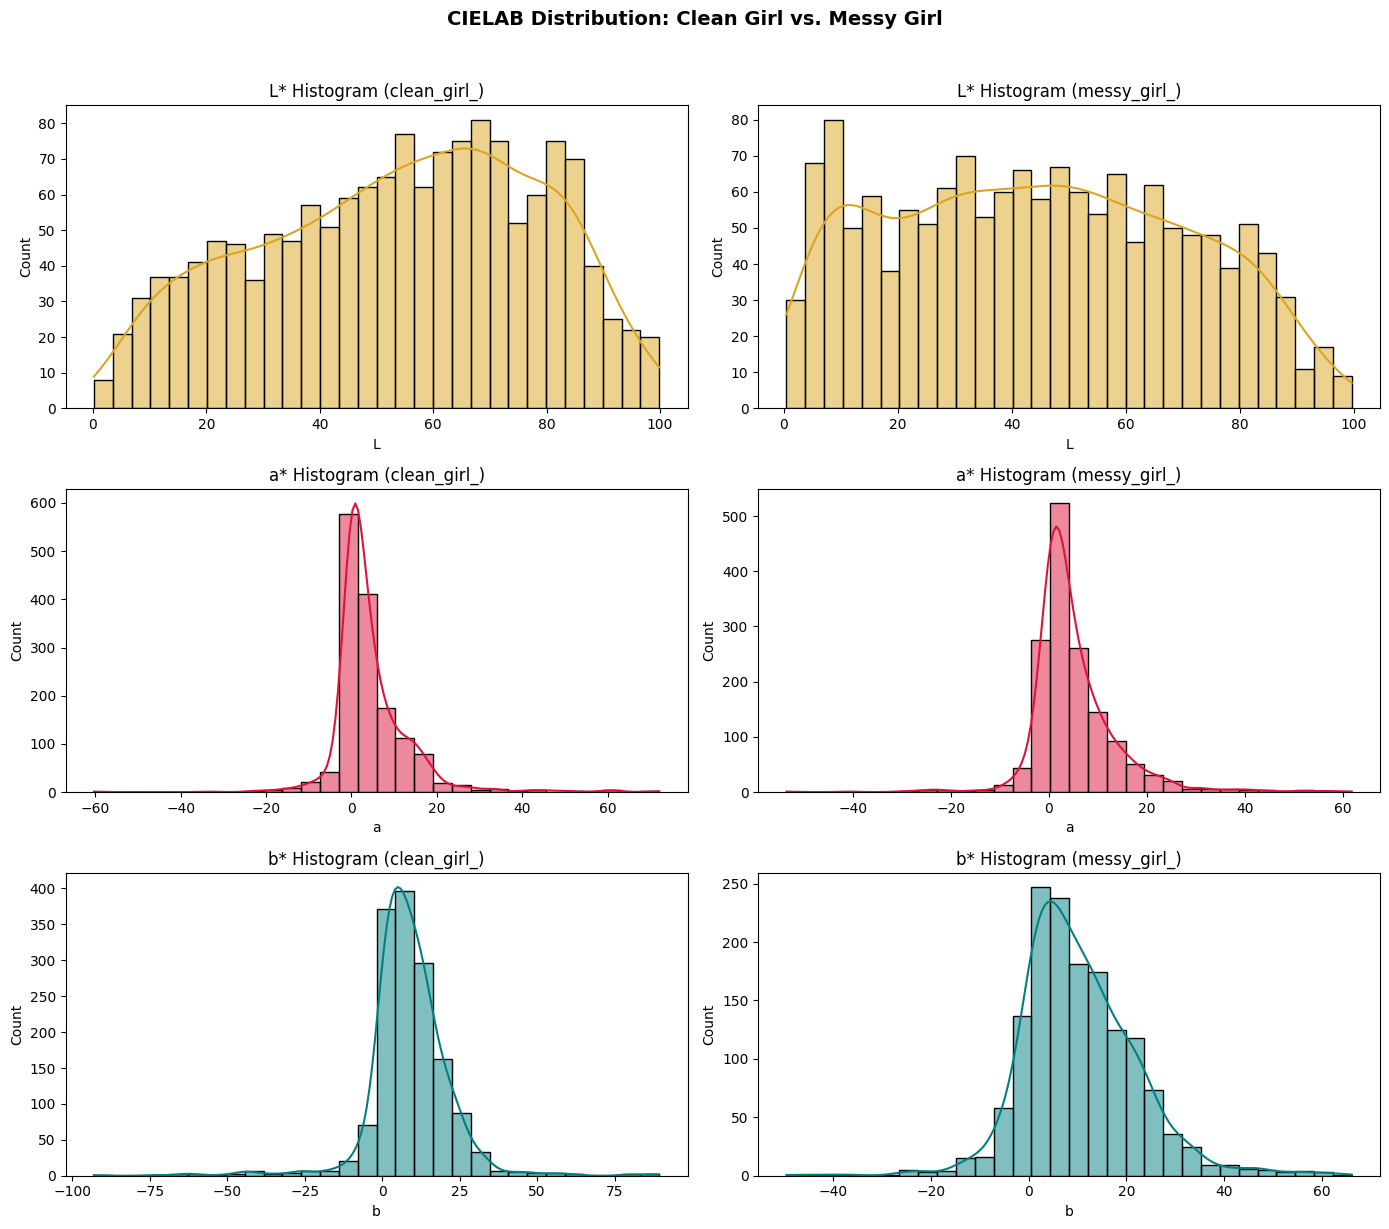

In [22]:
# L*, a*, b* histograms (side-by-side comparison)
import seaborn as sns

def plot_lab_histograms_compared(palette_df):
    trends = ["clean_girl_", "messy_girl_"]
    channels = [("L", "goldenrod"), ("a", "crimson"), ("b", "teal")]

    fig, axes = plt.subplots(3, 2, figsize=(14, 12))

    for row_idx, (channel, color) in enumerate(channels):
        for col_idx, trend in enumerate(trends):
            subset = palette_df[palette_df["trend"] == trend]

            sns.histplot(
                subset[channel],
                bins=30,
                kde=True,
                ax=axes[row_idx][col_idx],
                color=color
            )
            axes[row_idx][col_idx].set_title(f"{channel}* Histogram ({trend})")
            axes[row_idx][col_idx].set_xlabel(channel)
            axes[row_idx][col_idx].set_ylabel("Count")

    plt.suptitle("CIELAB Distribution: Clean Girl vs. Messy Girl",
                 fontsize=14, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()

plot_lab_histograms_compared(palette_df)

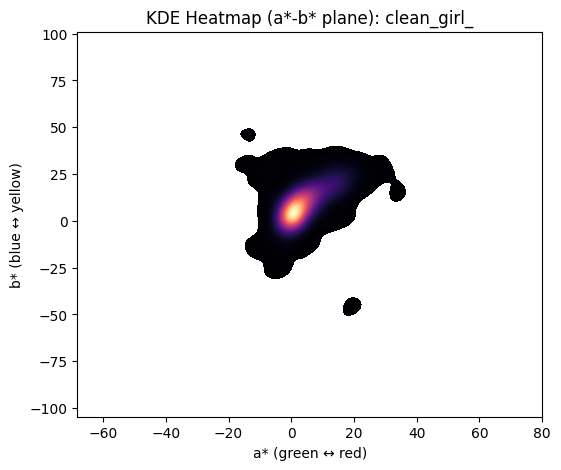

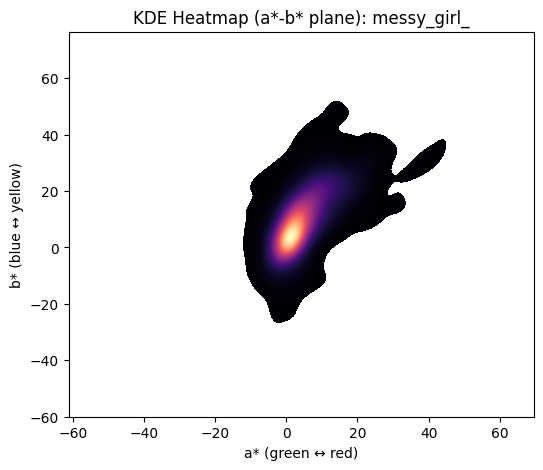

In [23]:
# KDE heatmaps in a*-b* plane
def plot_ab_kde(palette_df, trend_name):
    subset = palette_df[palette_df["trend"] == trend_name]

    plt.figure(figsize=(6, 5))
    sns.kdeplot(
        x=subset["a"],
        y=subset["b"],
        fill=True,
        cmap="magma",
        thresh=0.05,
        levels=100
    )
    plt.title(f"KDE Heatmap (a*-b* plane): {trend_name}")
    plt.xlabel("a* (green ↔ red)")
    plt.ylabel("b* (blue ↔ yellow)")
    plt.show()

plot_ab_kde(palette_df, "clean_girl_")
plot_ab_kde(palette_df, "messy_girl_")

## Export results

In [24]:
# Pivot to wide format for merging with original dataframe
# HEX colors
hex_wide = palette_df.pivot_table(
    index="pin_id",
    columns="cluster",
    values="hex",
    aggfunc="first"
)
hex_wide.columns = [f"hex_{i+1}" for i in hex_wide.columns]
hex_wide = hex_wide.reset_index()

# LAB + Proportion
lab_wide = palette_df.pivot_table(
    index="pin_id",
    columns="cluster",
    values=["L", "a", "b", "proportion"],
    aggfunc="first"
)
lab_wide.columns = [f"{val}_{cluster}" for val, cluster in lab_wide.columns]
lab_wide = lab_wide.reset_index()

# Merge with original dataframe
df_merged = df \
    .merge(lab_wide, on="pin_id", how="left") \
    .merge(hex_wide, on="pin_id", how="left")

# Save
output_path = "/content/drive/MyDrive/Team Dattel/Computational Social Media Analysis/Preprocessing Data/combined_colors.csv"
df_merged.to_csv(output_path, index=False)

print(f"Saved: {output_path}")
print(f"Columns: {len(df_merged.columns)}")
print(f"Original columns: {len(df.columns)} → With colors: {len(df_merged.columns)}")

df_merged.head()

Saved: /content/drive/MyDrive/Team Dattel/Computational Social Media Analysis/Preprocessing Data/combined_colors.csv
Columns: 34
Original columns: 9 → With colors: 34


,pin_id,title,description,domain,board,created_at,image_url,category,full_path,L_0,...,proportion_0,proportion_1,proportion_2,proportion_3,proportion_4,hex_1,hex_2,hex_3,hex_4,hex_5
0,21251429487397507,NaN,NaN,Uploaded by user,Lifestyle,"Wed, 22 Oct 2025 07:20:25 +0000",https://i.pinimg.com/originals/09/e9/a3/09e9a3...,clean_girl_,https://i.pinimg.com/originals/09/e9/a3/09e9a3...,56.995589,...,0.268365,0.143981,0.324445,0.035343,0.227866,#97847f,#d5d3cd,#acaaa3,#5e4b47,#d4b8b4
1,281543725716857,NaN,NaN,Uploaded by user,aesthetic inspo,"Sun, 22 Jun 2025 21:00:24 +0000",https://i.pinimg.com/originals/e2/99/49/e29949...,clean_girl_,https://i.pinimg.com/originals/e2/99/49/e29949...,86.942327,...,0.291544,0.133614,0.260294,0.234400,0.080149,#cfdbe0,#674938,#b2b8ba,#382b20,#907f70
2,Ad4Jj0M0b2zAQG3867WSlOAYg40oMTT84o3eKc5sz0NwHb...,syoss Intense Keratin,Entdecke jetzt die syoss Intense Keratin Pfleg...,syoss.de,Ad-only Pins,"Thu, 08 Jan 2026 13:07:16 +0000",https://i.pinimg.com/originals/49/2c/90/492c90...,clean_girl_,https://i.pinimg.com/originals/49/2c/90/492c90...,10.347069,...,0.325754,0.090460,0.307808,0.066671,0.209306,#211a1a,#a9745c,#6b5f55,#c09779,#3f3530
3,AU2ScxmiEIV1SpLi8wNppJ4U0vFgnZM3dtKi96S7qDYJE4...,Dein neuer Long-Hair Fav!✨,"Langes Haar? Hol dir die Pflege, die es verdie...",dm.de,Nur als Anzeigen gedachte Pins,"Thu, 20 Nov 2025 17:54:23 +0000",https://i.pinimg.com/originals/30/43/82/304382...,clean_girl_,https://i.pinimg.com/originals/30/43/82/304382...,76.016017,...,0.472758,0.058351,0.037964,0.175271,0.255657,#b3bcc4,#e58d8c,#213a8b,#dcdfe9,#8896a3
4,119556565105668720,NaN,NaN,Uploaded by user,2026 vision board,"Fri, 02 Jan 2026 05:46:44 +0000",https://i.pinimg.com/originals/e5/fb/d9/e5fbd9...,clean_girl_,https://i.pinimg.com/originals/e5/fb/d9/e5fbd9...,82.930924,...,0.306725,0.131479,0.054465,0.343915,0.163415,#d5cebd,#674421,#341d07,#ada189,#8e7156
